In [ ]:
# =========================================
# Cell 1 — Installs (Colab)
# =========================================
!pip install -q pandas numpy scikit-learn xgboost


In [ ]:
import pandas as pd, numpy as np
from datetime import datetime
from pathlib import Path

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    classification_report, r2_score, mean_squared_error, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder

# Global config (month-level)
HOLDOUT_START = pd.Timestamp("2025-01-01")
HOLDOUT_END   = pd.Timestamp("2025-12-01")
BURN_START    = pd.Timestamp("2021-04-01")
RANDOM_STATE  = 42

# Get the year string for dynamic naming/printing
HOLDOUT_YEAR_STR = str(HOLDOUT_START.year)

# Speed toggle for quick trial (None for full run; or set an int like 40)
SPEED_SUBSET_N = None

In [ ]:
# =========================================
# Cell 3 — Mount Drive (Colab)
# =========================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# =========================================
# Cell 4 — Paths & load raw data
# =========================================
# Update these if your files live elsewhere
DATA_FIN   = '/content/drive/MyDrive/FinData.csv'
DATA_COST  = '/content/drive/MyDrive/Cost explanation - Sheet1.csv'  # optional
DATA_EXPH  = '/content/drive/MyDrive/Expense code explanation - Sheet1.csv'  # optional
OVERRIDES_CSV = '/content/drive/MyDrive/behavior_overrides.csv'  # optional

# Load
fin         = pd.read_csv(DATA_FIN)
cost_lookup = pd.read_csv(DATA_COST)  if Path(DATA_COST).exists()  else pd.DataFrame()
exp_lookup  = pd.read_csv(DATA_EXPH)  if Path(DATA_EXPH).exists()  else pd.DataFrame()

# Standardize column names -> adjust left-side keys to your CSV headers
rename_map = {
    'Cost Centre'   : 'cost_centre',
    'Expense Head'  : 'expense_head',
    'Actuals'       : 'actual_effective',
    'Budget'        : 'budget_effective',  # Corrected Budget column name
}
fin = fin.rename(columns=rename_map)

# Create 'date' column from 'Period' and 'Year'
def parse_fiscal_year(year, period):
    year_str = str(year)
    # Example logic: fiscal '2425' -> start year 2024
    if len(year_str) == 4 and year_str.isdigit():
        start_year = int(year_str[:2]) + 2000
        return f'{start_year}-{int(period):02d}-01'
    # Otherwise treat as standard calendar year like 2023
    return f'{int(year)}-{int(period):02d}-01'

fin['date'] = fin.apply(lambda row: parse_fiscal_year(row['Year'], row['Period']), axis=1)
fin['date'] = pd.to_datetime(fin['date']).dt.to_period('M').dt.to_timestamp()

# Minimal columns required
need = ['cost_centre','expense_head','date','actual_effective','budget_effective']
missing = [c for c in need if c not in fin.columns]
if missing:
    raise ValueError(f"Missing columns in FinData.csv: {missing}")

# Types
fin['actual_effective'] = pd.to_numeric(fin['actual_effective'], errors='coerce')
fin['budget_effective'] = pd.to_numeric(fin['budget_effective'], errors='coerce')

# Effective frame for the pipeline
eff = fin[['cost_centre','expense_head','date','actual_effective','budget_effective']].copy()

print("Loaded rows:", len(eff))
print("Date range:", eff['date'].min(), "→", eff['date'].max())


/tmp/ipython-input-2662399582.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  fin         = pd.read_csv(DATA_FIN)


Loaded rows: 694868
Date range: 2021-01-01 00:00:00 → 2025-12-01 00:00:00


In [ ]:
# =========================================
# Cell 5 — Classification helpers (features, rules, model)
# =========================================
def make_cls_features(df):
    """
    df: cost_centre, expense_head, date, actual_effective, budget_effective
    Returns per-month features for behaviour classification.
    """
    df = df.sort_values(['cost_centre','expense_head','date']).copy()
    out = []
    for (cc, eh), g in df.groupby(['cost_centre','expense_head'], sort=False):
        g = g.copy()
        y = g['actual_effective'].fillna(0.0)

        g['active_12']       = y.shift(1).rolling(12, min_periods=3).apply(lambda s: (s>0).sum(), raw=True)
        g['mean_12']         = y.shift(1).rolling(12, min_periods=3).mean()
        g['std_12']          = y.shift(1).rolling(12, min_periods=3).std()
        g['cv_12']           = (g['std_12'] / g['mean_12'].replace(0,np.nan)).fillna(0)
        g['peak_ratio_12']   = y.shift(1).rolling(12, min_periods=3).apply(
            lambda s: (np.nan if s.mean()==0 else s.max()/s.mean()), raw=True)
        lag1                 = y.shift(1)
        g['delta1']          = (y - lag1).abs()
        g['delta1_mean_12']  = g['delta1'].shift(1).rolling(12, min_periods=3).mean()

        nz                   = (y>0).astype(int)
        grp                  = (nz!=nz.shift()).cumsum()
        g['gap_run']         = (nz==0).groupby(grp).cumsum()
        g['max_gap_12']      = g['gap_run'].shift(1).rolling(12, min_periods=3).max()

        g['prop_nonzero_12'] = y.shift(1).rolling(12, min_periods=3).apply(lambda s: (s>0).mean(), raw=True)

        cols = ['active_12','mean_12','std_12','cv_12','peak_ratio_12',
                'delta1_mean_12','max_gap_12','prop_nonzero_12']
        out.append(g[['cost_centre','expense_head','date'] + cols])
    return pd.concat(out, ignore_index=True)

def weak_label(row):
    # Transparent initial rules (tune later)
    if (row['prop_nonzero_12'] >= 0.75) and (row['cv_12'] <= 1.0):
        return "Recurring"
    if (pd.notna(row['peak_ratio_12']) and row['peak_ratio_12'] >= 2.0) and (row['prop_nonzero_12'] >= 0.25):
        return "Seasonal"
    if (row['active_12'] <= 2) and (row['max_gap_12'] >= 6):
        return "One-Off"
    if (row['prop_nonzero_12'] <= 0.05) and (row['active_12'] == 0):
        return "Discontinued"
    return "Recurring"

def train_and_score_classifier(eff_df):
    feats = make_cls_features(eff_df).sort_values(['cost_centre','expense_head','date']).copy()
    feats['label'] = feats.apply(weak_label, axis=1)

    cls_cols = [c for c in feats.columns if c not in ['cost_centre','expense_head','date','label']]
    train_m = feats['date'] <  HOLDOUT_START
    test_m  = (feats['date'] >= HOLDOUT_START) & (feats['date'] <= HOLDOUT_END)

    X_train, y_train = feats.loc[train_m, cls_cols], feats.loc[train_m, 'label']
    X_test,  y_test  = feats.loc[test_m,  cls_cols], feats.loc[test_m,  'label']

    # Encode string labels -> ints
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test) if len(y_test) else y_test

    cls = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='mlogloss', tree_method='hist', n_jobs=-1,
        random_state=RANDOM_STATE
    )
    cls.fit(X_train, y_train_enc)

    if len(X_test):
        print("\n=== Behaviour Classification (2024 holdout) ===")
        print("[Note] Trained on rule-derived labels; accuracy/F1 are not real-world yet.")

    # Predict all rows
    all_pred_enc = cls.predict(feats[cls_cols])
    all_pred = le.inverse_transform(all_pred_enc)
    proba = cls.predict_proba(feats[cls_cols])
    proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in le.classes_])

    cls_pred = pd.concat([
        feats[['cost_centre','expense_head','date']].reset_index(drop=True),
        pd.Series(all_pred, name='behavior_pred'),
        proba_df.reset_index(drop=True)
    ], axis=1)

    # attach encoder for later if you want to save model
    cls.label_encoder_ = le
    return cls, cls_pred


In [ ]:
# =========================================
# Cell 6 — Manual override helpers (apply + CSV reader)
# =========================================
def apply_behaviour_overrides(pred_df, overrides_df):
    """
    pred_df: output of classifier (behavior_pred + prob_*)
    overrides_df: optional manual labels CSV with columns:
        cost_centre, expense_head, date, manual_label
    Returns: pred_df + behavior_final + source ('auto'/'manual')
    """
    df = pred_df.merge(overrides_df, on=['cost_centre','expense_head','date'], how='left')
    df['behavior_final'] = np.where(df['manual_label'].notna(), df['manual_label'], df['behavior_pred'])
    df['source'] = np.where(df['manual_label'].notna(), 'manual', 'auto')
    return df.drop(columns=['manual_label'])

def read_overrides_csv(path_str=None):
    if not path_str:
        return pd.DataFrame(columns=['cost_centre','expense_head','date','manual_label'])
    p = Path(path_str)
    if not p.exists():
        print(f"[Info] Overrides file not found at: {p} -> proceeding without.")
        return pd.DataFrame(columns=['cost_centre','expense_head','date','manual_label'])

    ov = pd.read_csv(p)

    # normalize columns
    rename = {'Cost Centre':'cost_centre','Expense Head':'expense_head','Manual Label':'manual_label'}
    ov = ov.rename(columns={k:v for k,v in rename.items() if k in ov.columns})

    needed = ['cost_centre','expense_head','date','manual_label']
    miss = [c for c in needed if c not in ov.columns]
    if miss:
        raise ValueError(f"Overrides CSV missing columns: {miss}")

    # date -> month start (to match pipeline)
    ov['date'] = pd.to_datetime(ov['date'], errors='coerce').dt.to_period('M').dt.to_timestamp()

    # title-case & validate labels
    ov['manual_label'] = ov['manual_label'].astype(str).str.strip().str.title()
    valid = {'Recurring','Seasonal','One-Off','Discontinued'}
    bad = ~ov['manual_label'].isin(valid)
    if bad.any():
        bad_vals = sorted(ov.loc[bad,'manual_label'].unique().tolist())
        raise ValueError(f"Overrides contain invalid labels {bad_vals}. Use one of {sorted(valid)}.")
    return ov


In [ ]:
# =========================================
# Cell 7 — Forecast feature engineering + model (fast)
# =========================================
def build_forecast_features(eff_df, behavior_final_df):
    # keep only Recurring + Seasonal for forecasting
    df = eff_df.merge(
        behavior_final_df[['cost_centre','expense_head','date','behavior_final']],
        on=['cost_centre','expense_head','date'], how='left'
    )
    df = df[df['behavior_final'].isin(['Recurring','Seasonal'])].copy()

    df = df.rename(columns={'actual_effective':'actuals','budget_effective':'budget'})
    df = df.sort_values(['cost_centre','expense_head','date'])

    def add_feats(g):
        g = g.copy()
        s = g['actuals']

        # Lags
        for lag in [1,2,3,6,12,18,24]:
            g[f'lag_{lag}'] = s.shift(lag)

        # Rolling stats (shifted)
        g['roll3_mean']  = s.shift(1).rolling(3).mean()
        g['roll6_mean']  = s.shift(1).rolling(6).mean()
        g['roll12_mean'] = s.shift(1).rolling(12).mean()

        g['roll3_std']   = s.shift(1).rolling(3).std()
        g['roll6_std']   = s.shift(1).rolling(6).std()
        g['roll12_std']  = s.shift(1).rolling(12).std()

        # Growth / ratio
        g['yoy'] = s / g['lag_12']
        g['yoy'] = g['yoy'].replace([np.inf,-np.inf], np.nan).fillna(1.0)
        g['mom'] = s / g['lag_1']
        g['mom'] = g['mom'].replace([np.inf,-np.inf], np.nan).fillna(1.0)

        # Budget interaction
        if 'budget' in g.columns:
            g['budget_lag1'] = g['budget'].shift(1)
            g['budget_ratio'] = g['actuals'] / g['budget'].replace(0,np.nan)

        # Calendar encodings
        g['month'] = g['date'].dt.month
        g['quarter'] = g['date'].dt.quarter
        g['year'] = g['date'].dt.year

        # Cyclical month
        g['m_sin'] = np.sin(2*np.pi*g['month']/12)
        g['m_cos'] = np.cos(2*np.pi*g['month']/12)

        return g

    feat_df = pd.concat(
        [add_feats(g) for _, g in df.groupby(['cost_centre','expense_head'], sort=False)],
        ignore_index=True
    )
    feat_df = feat_df[feat_df['date'] >= BURN_START].copy()
    feat_df = feat_df.dropna(subset=['actuals'])
    return feat_df

def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def train_and_eval_forecaster(feat_df):
    # Lean feature set for speed
    X_cols = [c for c in [
        'lag_1','lag_2','lag_3','lag_6','lag_12','lag_18','lag_24',
        'roll3_mean','roll6_mean','roll12_mean',
        'roll3_std','roll6_std','roll12_std',
        'yoy','mom',
        'budget_lag1','budget_ratio',
        'm_sin','m_cos',
        'month','quarter','year'
    ] if c in feat_df.columns]

    train = feat_df[feat_df['date'] <  HOLDOUT_START]
    test  = feat_df[(feat_df['date'] >= HOLDOUT_START) & (feat_df['date'] <= HOLDOUT_END)]

    print("Train:", train['date'].min(), "→", train['date'].max(), "rows:", len(train))
    print("Test :", test['date'].min(),  "→", test['date'].max(),  "rows:", len(test))

    if len(train)==0 or len(test)==0 or len(X_cols)==0:
        print("Not enough rows/features for training or testing.")
        return None, None

    Xtr, ytr = train[X_cols], train['actuals']
    Xte, yte = test[X_cols],  test['actuals']

    mdl = XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9,
        tree_method='hist', n_jobs=-1,
        random_state=RANDOM_STATE
    )
    mdl.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    pred = mdl.predict(Xte)

    r2   = r2_score(yte, pred)
    rmse = rmse_score(yte, pred)
    mae  = mean_absolute_error(yte, pred)
    print(f"\n=== Forecast (holdout {HOLDOUT_YEAR_STR}) ===\nR² : {r2:.3f}\nRMSE: {rmse:,.2f}\nMAE : {mae:,.2f}")

    # baselines
    if 'lag_1' in X_cols:
        naive = test['lag_1']; mask = ~naive.isna()
        if mask.any():
            r2n  = r2_score(yte[mask], naive[mask])
            rmn  = rmse_score(yte[mask], naive[mask])
            man  = mean_absolute_error(yte[mask], naive[mask])
            print(f"Naive (lag_1)  R²: {r2n:.3f} | RMSE: {rmn:,.2f} | MAE: {man:,.2f}")
    if 'lag_12' in X_cols:
        snaive = test['lag_12']; mask12 = ~snaive.isna()
        if mask12.any():
            r2s  = r2_score(yte[mask12], snaive[mask12])
            rms  = rmse_score(yte[mask12], snaive[mask12])
            mas  = mean_absolute_error(yte[mask12], snaive[mask12])
            print(f"S-Naive(lag_12) R²: {r2s:.3f} | RMSE: {rms:,.2f} | MAE: {mas:,.2f}")

    preview = (test[['cost_centre','expense_head','date','actuals']].copy()
               .assign(forecast=pred))
    print("\nSample predictions:")
    print(preview.head(12).to_string(index=False))
    return mdl, preview

In [ ]:
# =========================================
# Cell 8 — Summary report (tables + exports)
# =========================================
def build_summary(labels_df, preview_df, proba_prefix='prob_'):
    out = {}

    # 1) Predicted vs Final label counts
    out['label_counts_pred']  = labels_df['behavior_pred'].value_counts(dropna=False).rename_axis('behavior').reset_index(name='count')
    out['label_counts_final'] = labels_df['behavior_final'].value_counts(dropna=False).rename_axis('behavior').reset_index(name='count')

    # 2) Source distribution
    if 'source' in labels_df.columns:
        out['source_counts'] = labels_df['source'].value_counts(dropna=False).rename_axis('source').reset_index(name='count')

    # 3) Rows changed due to overrides
    if 'source' in labels_df.columns:
        changed = labels_df[labels_df['source']=='manual'].copy()
        changed = changed[changed['behavior_pred'] != changed['behavior_final']]
        out['changed_due_to_overrides'] = changed[['cost_centre','expense_head','date','behavior_pred','behavior_final']]

    # 4) Low-confidence candidates (max prob < 0.60)
    prob_cols = [c for c in labels_df.columns if c.startswith(proba_prefix)]
    if prob_cols:
        tmp = labels_df.copy()
        tmp['max_prob'] = tmp[prob_cols].max(axis=1)
        low = tmp[tmp['max_prob'] < 0.60].copy()
        low = low.sort_values('max_prob')
        out['low_confidence'] = low[['cost_centre','expense_head','date','behavior_pred','max_prob']].head(250)

    # 5) Forecast KPIs for holdout (preview_df)
    if preview_df is not None and len(preview_df):
        kpi = {}
        kpi['rows'] = int(len(preview_df))
        kpi['actual_sum']   = float(preview_df['actuals'].sum())
        kpi['forecast_sum'] = float(preview_df['forecast'].sum())
        denom = preview_df['actuals'].replace(0, np.nan)
        ape = (preview_df['forecast'] - preview_df['actuals']).abs() / denom
        kpi['mape_like'] = float(np.nanmean(ape) * 100.0)
        out[f'forecast_kpis_{HOLDOUT_YEAR_STR}'] = pd.DataFrame([kpi])

        errs = preview_df.copy()
        errs['abs_err'] = (errs['forecast'] - errs['actuals']).abs()
        out['top_abs_errors'] = errs.sort_values('abs_err', ascending=False).head(50)[
            ['cost_centre','expense_head','date','actuals','forecast','abs_err']
        ]

    return out

def save_summary_to_drive(summary_dict, out_dir='/content/drive/MyDrive/ai_pipeline_summaries'):
    outp = Path(out_dir)
    outp.mkdir(parents=True, exist_ok=True)

    if 'label_counts_pred' in summary_dict:
        summary_dict['label_counts_pred'].to_csv(outp/'label_counts_pred.csv', index=False)
    if 'label_counts_final' in summary_dict:
        summary_dict['label_counts_final'].to_csv(outp/'label_counts_final.csv', index=False)
    if 'source_counts' in summary_dict:
        summary_dict['source_counts'].to_csv(outp/'label_source_counts.csv', index=False)
    if 'changed_due_to_overrides' in summary_dict:
        summary_dict['changed_due_to_overrides'].to_csv(outp/'changed_due_to_overrides.csv', index=False)
    if 'low_confidence' in summary_dict:
        summary_dict['low_confidence'].to_csv(outp/'low_confidence_candidates.csv', index=False)
    if f'forecast_kpis_{HOLDOUT_YEAR_STR}' in summary_dict:
        summary_dict[f'forecast_kpis_{HOLDOUT_YEAR_STR}'].to_csv(outp/f'forecast_kpis_{HOLDOUT_YEAR_STR}.csv', index=False)
    if 'top_abs_errors' in summary_dict:
        summary_dict['top_abs_errors'].to_csv(outp/f'forecast_top_abs_errors_{HOLDOUT_YEAR_STR}.csv', index=False)

    print(f"\nSaved summary CSVs to: {outp}")

In [ ]:
# # =========================================
# # Cell 9 — Prep base & read overrides (now safe to call)
# # =========================================
# # Optional subset for speed
# base = eff.copy()
# if SPEED_SUBSET_N is not None:
#     groups = base[['cost_centre','expense_head']].drop_duplicates().head(SPEED_SUBSET_N)
#     base = base.merge(groups, on=['cost_centre','expense_head'])

# # Read overrides (returns empty DF with correct schema if file missing)
# overrides_df = read_overrides_csv(OVERRIDES_CSV)
# print("Overrides rows:", len(overrides_df))


In [ ]:
# NEW CELL 9=== Config for stricter One-Off (Ferrari-style) =============================
MIN_ONEOFF_AMOUNT = 100.0   # floor to ignore tiny amounts (set to 0.0 if not needed)
CC_SPIKE_MULT     = 4.0     # how many × typical CC month qualifies as a spike

# === Features ================================================================
def make_cls_features(df):
    """
    Builds per-month features for behaviour classification.
    Adds y_curr (current month actual, NaN->0).
    """
    df = df.sort_values(['cost_centre','expense_head','date']).copy()
    out = []
    for (cc, eh), g in df.groupby(['cost_centre','expense_head'], sort=False):
        g = g.copy()
        y = g['actual_effective'].fillna(0.0)

        g['y_curr']          = y  # <-- used in strict One-Off rule
        g['active_12']       = y.shift(1).rolling(12, min_periods=3).apply(lambda s: (s>0).sum(), raw=True)
        g['mean_12']         = y.shift(1).rolling(12, min_periods=3).mean()
        g['std_12']          = y.shift(1).rolling(12, min_periods=3).std()
        g['cv_12']           = (g['std_12'] / g['mean_12'].replace(0,np.nan)).fillna(0)
        g['peak_ratio_12']   = y.shift(1).rolling(12, min_periods=3).apply(
            lambda s: (np.nan if s.mean()==0 else s.max()/s.mean()), raw=True)
        lag1                 = y.shift(1)
        g['delta1']          = (y - lag1).abs()
        g['delta1_mean_12']  = g['delta1'].shift(1).rolling(12, min_periods=3).mean()

        nz                   = (y>0).astype(int)
        grp                  = (nz!=nz.shift()).cumsum()
        g['gap_run']         = (nz==0).groupby(grp).cumsum()
        g['max_gap_12']      = g['gap_run'].shift(1).rolling(12, min_periods=3).max()
        g['prop_nonzero_12'] = y.shift(1).rolling(12, min_periods=3).apply(lambda s: (s>0).mean(), raw=True)

        cols = ['y_curr','active_12','mean_12','std_12','cv_12','peak_ratio_12',
                'delta1_mean_12','max_gap_12','prop_nonzero_12']
        out.append(g[['cost_centre','expense_head','date'] + cols])
    return pd.concat(out, ignore_index=True)

# === Usual/Novel/Typical context built from history BEFORE HOLDOUT ===========
def build_usual_sets(eff_df, cutoff_date, min_months=4, min_share=0.02):
    """
    Compute context using data strictly before cutoff_date:
      - is_usual_cc: expense is usual for this cost centre (months_active>=min_months OR share>=min_share)
      - is_usual_org: expense head is common org-wide (loose)
      - seen_pre_cutoff: pair (cc, expense) existed before
      - cc_month_median: typical monthly spend for cost centre (median of non-zero months)
    """
    hist = eff_df[eff_df['date'] < cutoff_date].copy()
    hist['amt'] = hist['actual_effective'].fillna(0.0)

    # totals & active months per (cc, exp)
    cc_totals = hist.groupby('cost_centre', as_index=False)['amt'].sum().rename(columns={'amt':'cc_total'})
    pair = hist.groupby(['cost_centre','expense_head'], as_index=False).agg(
        pair_total=('amt','sum'),
        months_active=('amt', lambda s: (s>0).sum())
    )
    shares = pair.merge(cc_totals, on='cost_centre', how='left')
    shares['share'] = shares['pair_total'] / shares['cc_total'].replace(0, np.nan)
    usual_cc = shares.assign(is_usual_cc=lambda d: (d['months_active'] >= min_months) | (d['share'] >= min_share))[
        ['cost_centre','expense_head','is_usual_cc']
    ]

    # org-wide usual expense heads
    org_exp = hist.groupby('expense_head', as_index=False)['amt'].sum().rename(columns={'amt':'org_total'})
    org_months = hist.groupby('expense_head', as_index=False).agg(org_months_active=('amt', lambda s: (s>0).sum()))
    org_merged = org_exp.merge(org_months, on='expense_head', how='left')
    org_merged['is_usual_org'] = (org_merged['org_months_active'] >= (min_months * 3)) | (org_merged['org_total'] > 0)
    usual_org = org_merged[['expense_head','is_usual_org']]

    seen_pairs = pair[['cost_centre','expense_head']].drop_duplicates()
    seen_pairs['seen_pre_cutoff'] = True

    # typical monthly spend per cost centre (median of non-zero months)
    cc_month = hist.groupby(['cost_centre','date'], as_index=False)['amt'].sum()
    cc_typical = (cc_month.assign(nz=lambda d: d['amt'].where(d['amt']>0))
                           .groupby('cost_centre', as_index=False)['nz'].median()
                           .rename(columns={'nz':'cc_month_median'}))
    cc_typical['cc_month_median'] = cc_typical['cc_month_median'].fillna(0.0)

    return {
        'usual_cc': usual_cc,
        'usual_org': usual_org,
        'seen_pairs': seen_pairs,
        'cc_typical': cc_typical
    }

# === Business-aligned weak label (uses y_curr + usual sets) ==================
def weak_label(row):
    # Recurring: frequent & reasonably stable
    if (row['prop_nonzero_12'] >= 0.75) and (row['cv_12'] <= 1.0):
        return "Recurring"

    # Seasonal: strong peaks with some regular activity
    if (pd.notna(row['peak_ratio_12']) and row['peak_ratio_12'] >= 2.0) and (row['prop_nonzero_12'] >= 0.25):
        return "Seasonal"

    # One-Off: not usual (for CC), current positive spend, no prior-12 activity
    cond_A = (not bool(row.get('is_usual_cc', False))) and (row['y_curr'] >= MIN_ONEOFF_AMOUNT) and (row['active_12'] == 0)
    # OR: pair never seen before cutoff and decent size
    cond_B = (not bool(row.get('seen_pre_cutoff', False))) and (row['y_curr'] >= MIN_ONEOFF_AMOUNT)
    # OR: very large spike vs typical CC month and not usual
    typical = row.get('cc_month_median', 0.0)
    cond_C = (row['y_curr'] >= CC_SPIKE_MULT * max(typical, 1.0)) and (not bool(row.get('is_usual_cc', False)))

    if cond_A or cond_B or cond_C:
        return "One-Off"

    # Discontinued: nothing now & inactive historically
    if (row['y_curr'] == 0) and (row['prop_nonzero_12'] <= 0.05) and (row['active_12'] == 0):
        return "Discontinued"

    # Fallback
    return "Recurring"

# === Classifier (same signature; Cell 10 driver remains unchanged) ===========
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

def train_and_score_classifier(eff_df, show_scores=True):
    # Base features
    feats = make_cls_features(eff_df).sort_values(['cost_centre','expense_head','date']).copy()

    # Merge Ferrari-style context built from pre-holdout history
    extra = build_usual_sets(eff_df, cutoff_date=HOLDOUT_START, min_months=4, min_share=0.02)
    feats = feats.merge(extra['usual_cc'],  on=['cost_centre','expense_head'], how='left')
    feats = feats.merge(extra['usual_org'], on=['expense_head'],             how='left')
    feats = feats.merge(extra['seen_pairs'],on=['cost_centre','expense_head'], how='left')
    feats = feats.merge(extra['cc_typical'],on=['cost_centre'],               how='left')
    feats['is_usual_cc']     = feats['is_usual_cc'].fillna(False)
    feats['is_usual_org']    = feats['is_usual_org'].fillna(False)
    feats['seen_pre_cutoff'] = feats['seen_pre_cutoff'].fillna(False)
    feats['cc_month_median'] = feats['cc_month_median'].fillna(0.0)

    # Weak labels for training
    feats['label'] = feats.apply(weak_label, axis=1)

    # Train/test split for 2024 holdout
    cls_cols = [c for c in feats.columns if c not in ['cost_centre','expense_head','date','label']]
    train_m = feats['date'] <  HOLDOUT_START
    test_m  = (feats['date'] >= HOLDOUT_START) & (feats['date'] <= HOLDOUT_END)

    X_train, y_train = feats.loc[train_m, cls_cols], feats.loc[train_m, 'label']
    X_test,  y_test  = feats.loc[test_m,  cls_cols], feats.loc[test_m,  'label']

    # Encode labels
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test) if len(y_test) else y_test

    # Fit model
    cls = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='mlogloss', tree_method='hist', n_jobs=-1,
        random_state=RANDOM_STATE
    )
    cls.fit(X_train, y_train_enc)

    # Predict for ALL rows
    all_pred_enc = cls.predict(feats[cls_cols])
    all_pred = le.inverse_transform(all_pred_enc)
    proba = cls.predict_proba(feats[cls_cols])
    proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in le.classes_])

    cls_pred = pd.concat([
        feats[['cost_centre','expense_head','date']].reset_index(drop=True),
        pd.Series(all_pred, name='behavior_pred'),
        proba_df.reset_index(drop=True)
    ], axis=1)

    cls.label_encoder_ = le
    return cls, cls_pred
base = eff.copy()
if SPEED_SUBSET_N is not None:
    groups = base[['cost_centre','expense_head']].drop_duplicates().head(SPEED_SUBSET_N)
    base = base.merge(groups, on=['cost_centre','expense_head'])

# Empty overrides_df if you don’t yet have a manual labels CSV
overrides_df = pd.DataFrame(columns=['cost_centre','expense_head','date','manual_label'])


In [ ]:
# =========================================
# Cell 10 — Final A → B → C run (classification → overrides → forecast)
# =========================================
# A) Train classifier & predict
cls_model, cls_pred = train_and_score_classifier(base)

# B) Apply manual behaviour overrides
labels = apply_behaviour_overrides(cls_pred, overrides_df)

# What changed due to overrides?
if not overrides_df.empty:
    changed = labels.merge(
        cls_pred[['cost_centre','expense_head','date','behavior_pred']],
        on=['cost_centre','expense_head','date'],
        how='left', suffixes=('','_orig')
    )
    changed = changed[changed['behavior_final'] != changed['behavior_pred']]
    n_changed = len(changed)
    print(f"\n[Overrides] Rows changed by manual labels: {n_changed}")
    if n_changed:
        print(changed.head(10).to_string(index=False))
else:
    print("\n[Info] No overrides provided — using auto classifications only.")

# Quick real (manual) accuracy slice if you have manual rows
from sklearn.metrics import classification_report, f1_score
manual = labels[labels['source']=='manual'] if 'source' in labels.columns else pd.DataFrame()
if not manual.empty:
    y_true = manual['behavior_final']
    y_pred = manual['behavior_pred']
    print(f"\n=== Classifier vs MANUAL labels (only rows with manual labels for {HOLDOUT_YEAR_STR}) ===")
    print(classification_report(y_true, y_pred, digits=3))
    print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
else:
    print("\n[Info] No manual labels yet → skipping real accuracy evaluation.")

# C) Build forecast features & train forecaster (2024 holdout)
feat_df = build_forecast_features(base, labels)
mdl, preview = train_and_eval_forecaster(feat_df)

/tmp/ipython-input-886312903.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feats['is_usual_cc']     = feats['is_usual_cc'].fillna(False)
/tmp/ipython-input-886312903.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feats['is_usual_org']    = feats['is_usual_org'].fillna(False)
/tmp/ipython-input-886312903.py:131: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future


[Info] No overrides provided — using auto classifications only.

[Info] No manual labels yet → skipping real accuracy evaluation.
Train: 2021-04-01 00:00:00 → 2024-12-01 00:00:00 rows: 221914
Test : 2025-01-01 00:00:00 → 2025-12-01 00:00:00 rows: 40647

=== Forecast (holdout 2025) ===
R² : 0.765
RMSE: 73.19
MAE : 25.04
Naive (lag_1)  R²: -0.632 | RMSE: 171.03 | MAE: 54.35
S-Naive(lag_12) R²: -4.881 | RMSE: 314.42 | MAE: 188.83

Sample predictions:
cost_centre expense_head       date  actuals    forecast
      11021    121002000 2025-01-01  -168.84  -90.377083
      11021    121002000 2025-02-01   -41.32  -25.548710
      11021    121002000 2025-03-01     0.00   -4.447096
      11021    121020000 2025-01-01  -159.21 -198.702484
      11021    121020000 2025-02-01  -207.56 -337.279999
      11041    133008000 2025-03-01     0.00  204.296616
      11041    133015000 2025-06-01     0.00  157.069611
      11051    111301000 2025-02-01     0.00  133.663773
      11051    111301000 2025-03-0

In [ ]:
# =========================================
# Cell 11 — Optional: force-zero for Discontinued within holdout year
# =========================================
if preview is not None and len(preview):
    discon = labels[
        (labels['behavior_final']=='Discontinued') &
        (labels['date'].between(HOLDOUT_START, HOLDOUT_END))
    ][['cost_centre','expense_head']].drop_duplicates()

    if len(discon):
        key = ['cost_centre','expense_head']
        mask = preview[key].merge(discon, on=key, how='left', indicator=True)['_merge'].eq('both').values
        if mask.any():
            preview.loc[mask, 'forecast'] = 0.0
            print(f"[Info] Forced zero forecast for {mask.sum()} discontinued rows in holdout.")

[Info] Forced zero forecast for 7020 discontinued rows in holdout.


In [ ]:
# =========================================
# Cell 12 — Build summary + export CSVs (Power BI / Excel)
# =========================================
summary = build_summary(labels, preview)

print("\n=== Summary — Label distributions (PREDICTED) ===")
print(summary['label_counts_pred'].to_string(index=False))
print("\n=== Summary — Label distributions (FINAL) ===")
print(summary['label_counts_final'].to_string(index=False))

if 'source_counts' in summary:
    print("\n=== Summary — Source (auto vs manual) ===")
    print(summary['source_counts'].to_string(index=False))

if 'changed_due_to_overrides' in summary:
    print(f"\nOverrides changed {len(summary['changed_due_to_overrides'])} rows. Sample:")
    if len(summary['changed_due_to_overrides']):
        print(summary['changed_due_to_overrides'].head(12).to_string(index=False))

if 'low_confidence' in summary:
    print(f"\nLow-confidence candidates (<0.60): {len(summary['low_confidence'])}. Showing a few:")
    if len(summary['low_confidence']):
        print(summary['low_confidence'].head(12).to_string(index=False))

if 'forecast_kpis_2024' in summary:
    print("\n=== Forecast KPIs (2024 holdout) ===")
    print(summary['forecast_kpis_2024'].to_string(index=False))
    print("\nTop absolute errors (sample):")
    if 'top_abs_errors' in summary and len(summary['top_abs_errors']):
        print(summary['top_abs_errors'].head(10).to_string(index=False))

save_summary_to_drive(summary)

# Optional: save primary outputs for inspection / Power BI
labels.to_csv('/content/drive/MyDrive/behavior_labels_out.csv', index=False)
if preview is not None:
    preview.to_csv('/content/drive/MyDrive/predictions_out_2024.csv', index=False)
print("\nSaved: behavior_labels_out.csv, predictions_out_2024.csv")



=== Summary — Label distributions (PREDICTED) ===
    behavior  count
Discontinued 331776
   Recurring 281807
    Seasonal  79657
     One-Off   1628

=== Summary — Label distributions (FINAL) ===
    behavior  count
Discontinued 331776
   Recurring 281807
    Seasonal  79657
     One-Off   1628

=== Summary — Source (auto vs manual) ===
source  count
  auto 694868

Overrides changed 0 rows. Sample:

Low-confidence candidates (<0.60): 103. Showing a few:
cost_centre expense_head       date behavior_pred  max_prob
      CA020    421020000 2022-11-01      Seasonal  0.501420
      SD08W    451011000 2022-08-01      Seasonal  0.501483
      YE310    477003000 2024-03-01     Recurring  0.502457
      XH030    451011000 2023-10-01      Seasonal  0.502723
      TC170    421078000 2023-06-01     Recurring  0.502974
      TC170    421078000 2023-05-01     Recurring  0.504584
      DA14M    421044000 2021-07-01     Recurring  0.506408
      SD080    33102B000 2024-11-01     Recurring  0.507903


In [ ]:
# # =========================================
# # Cell 12 — Monthly reporting (totals) + summaries + exports
# # =========================================
# # (Assumes you already built `summary = build_summary(labels, preview)` earlier, or do it now)
# summary = build_summary(labels, preview)

# # --- Monthly totals across ALL cost centres/expense heads (global reporting)
# if preview is not None and len(preview):
#     monthly = (preview
#                .groupby('date', as_index=False)[['actuals','forecast']]
#                .sum())

#     # Metrics on monthly totals
#     from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#     r2_m   = r2_score(monthly['actuals'], monthly['forecast'])
#     rmse_m = mean_squared_error(monthly['actuals'], monthly['forecast'])
#     mae_m  = mean_absolute_error(monthly['actuals'], monthly['forecast'])

#     # Weighted MAPE (robust to small/negative actuals)
#     total_abs_err = (monthly['forecast'] - monthly['actuals']).abs().sum()
#     total_actual  = monthly['actuals'].abs().sum()
#     wmape = (total_abs_err / total_actual) * 100 if total_actual != 0 else np.nan

#     # Symmetric MAPE (handles zeros/negatives better)
#     smape = np.mean(
#         2 * (monthly['forecast'] - monthly['actuals']).abs() /
#         (monthly['forecast'].abs() + monthly['actuals'].abs() + 1e-9)
#     ) * 100

#     print("\n=== Forecast KPIs (Monthly Totals, 2024 holdout) ===")
#     print(f"R²   : {r2_m:.3f}")
#     print(f"RMSE : {rmse_m:,.2f}")
#     print(f"MAE  : {mae_m:,.2f}")
#     print(f"wMAPE: {wmape:.2f}%")
#     print(f"sMAPE: {smape:.2f}%")

#     print("\nSample monthly totals (actual vs forecast):")
#     print(monthly.head(12).to_string(index=False))

#     # Save monthly totals for reporting/Power BI
#     from pathlib import Path
#     OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
#     OUT_DIR.mkdir(parents=True, exist_ok=True)
#     monthly.to_csv(OUT_DIR/'monthly_totals_2024.csv', index=False)
#     print(f"\nSaved monthly totals to: {OUT_DIR/'monthly_totals_2024.csv'}")
# else:
#     print("\n[Info] No preview rows found for 2024 holdout; skipping monthly KPI block.")

# # --- (Optional) also print quick label/source summaries
# print("\n=== Summary — Label distributions (PREDICTED) ===")
# print(summary['label_counts_pred'].to_string(index=False))
# print("\n=== Summary — Label distributions (FINAL) ===")
# print(summary['label_counts_final'].to_string(index=False))
# if 'source_counts' in summary:
#     print("\n=== Summary — Source (auto vs manual) ===")
#     print(summary['source_counts'].to_string(index=False))

# # --- Save the rest of the summary tables
# save_summary_to_drive(summary)

# # --- Save primary row-level outputs too (for drill-down)
# labels.to_csv('/content/drive/MyDrive/behavior_labels_out.csv', index=False)
# if preview is not None:
#     preview.to_csv('/content/drive/MyDrive/predictions_out_2024.csv', index=False)
# print("\nSaved: behavior_labels_out.csv, predictions_out_2024.csv")


In [ ]:
# =========================================
# Cell 12 — Monthly reporting (totals) + summaries + exports
# =========================================
# (Assumes you already built `summary = build_summary(labels, preview)` earlier, or do it now)
summary = build_summary(labels, preview)

# --- Monthly totals across ALL cost centres/expense heads (global reporting)
if preview is not None and len(preview):
    monthly = (preview
               .groupby('date', as_index=False)[['actuals','forecast']]
               .sum())

    # Ensure numeric (in case something came through as object/string)
    monthly['actuals']  = pd.to_numeric(monthly['actuals'], errors='coerce')
    monthly['forecast'] = pd.to_numeric(monthly['forecast'], errors='coerce')

    # Manual RMSE (robust to old sklearn versions)
    residuals = monthly['forecast'] - monthly['actuals']
    rmse_m = float(np.sqrt(np.mean(np.square(residuals))))
    mae_m  = float(np.mean(np.abs(residuals)))
    r2_m   = r2_score(monthly['actuals'], monthly['forecast'])

    # Weighted MAPE on monthly totals
    total_abs_err = float(np.abs(residuals).sum())
    total_actual  = float(monthly['actuals'].abs().sum())
    wmape = (total_abs_err / total_actual) * 100 if total_actual != 0 else np.nan

    # Symmetric MAPE
    smape = float(np.mean(
        2 * np.abs(residuals) / (np.abs(monthly['forecast']) + np.abs(monthly['actuals']) + 1e-9)
    ) * 100)

    print("\n=== Forecast KPIs (Monthly Totals, 2024 holdout) ===")
    print(f"R²   : {r2_m:.3f}")
    print(f"RMSE : {rmse_m:,.2f}")
    print(f"MAE  : {mae_m:,.2f}")
    print(f"wMAPE: {wmape:.2f}%")
    print(f"sMAPE: {smape:.2f}%")


    print("\nSample monthly totals (actual vs forecast):")
    print(monthly.head(12).to_string(index=False))

    # Save monthly totals for reporting/Power BI
    from pathlib import Path
    OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    monthly.to_csv(OUT_DIR/'monthly_totals_2024.csv', index=False)
    print(f"\nSaved monthly totals to: {OUT_DIR/'monthly_totals_2024.csv'}")
else:
    print("\n[Info] No preview rows found for 2024 holdout; skipping monthly KPI block.")

# --- (Optional) also print quick label/source summaries
print("\n=== Summary — Label distributions (PREDICTED) ===")
print(summary['label_counts_pred'].to_string(index=False))
print("\n=== Summary — Label distributions (FINAL) ===")
print(summary['label_counts_final'].to_string(index=False))
if 'source_counts' in summary:
    print("\n=== Summary — Source (auto vs manual) ===")
    print(summary['source_counts'].to_string(index=False))

# --- Save the rest of the summary tables
save_summary_to_drive(summary)

# --- Save primary row-level outputs too (for drill-down)
labels.to_csv('/content/drive/MyDrive/behavior_labels_out.csv', index=False)
if preview is not None:
    preview.to_csv('/content/drive/MyDrive/predictions_out_2024.csv', index=False)
print("\nSaved: behavior_labels_out.csv, predictions_out_2024.csv")



=== Forecast KPIs (Monthly Totals, 2024 holdout) ===
R²   : 0.937
RMSE : 58,650.53
MAE  : 36,615.22
wMAPE: 34.92%
sMAPE: 167.86%

Sample monthly totals (actual vs forecast):
      date  actuals      forecast
2025-01-01 613231.4 659799.250000
2025-02-01 645095.2 692272.750000
2025-03-01      0.0 183355.796875
2025-04-01      0.0  30992.945312
2025-05-01      0.0  24823.382812
2025-06-01      0.0  19641.259766
2025-07-01      0.0  18695.859375
2025-08-01      0.0  17935.343750
2025-09-01      0.0  12220.172852
2025-10-01      0.0  13522.504883
2025-11-01      0.0  11962.784180
2025-12-01      0.0  12487.233398

Saved monthly totals to: /content/drive/MyDrive/ai_pipeline_summaries/monthly_totals_2024.csv

=== Summary — Label distributions (PREDICTED) ===
    behavior  count
Discontinued 331776
   Recurring 281807
    Seasonal  79657
     One-Off   1628

=== Summary — Label distributions (FINAL) ===
    behavior  count
Discontinued 331776
   Recurring 281807
    Seasonal  79657
     One-O

In [ ]:
# =========================================
# Cell 13 — Predicted variance vs Budget
# =========================================

# Merge budgets into preview
budget_cols = eff[['cost_centre','expense_head','date','budget_effective']].copy()
budget_cols = budget_cols.rename(columns={'budget_effective':'budget'})

preview_budget = preview.merge(budget_cols,
                               on=['cost_centre','expense_head','date'],
                               how='left')

# Compute predicted vs budget variance
preview_budget['pred_vs_budget_var'] = preview_budget['forecast'] - preview_budget['budget']
preview_budget['pred_vs_budget_abs'] = preview_budget['pred_vs_budget_var'].abs()
preview_budget['pred_vs_budget_pct'] = np.where(
    preview_budget['budget'].abs() > 1e-9,
    preview_budget['pred_vs_budget_var'] / preview_budget['budget'].replace(0, np.nan),
    np.nan
)

# Aggregate monthly totals (org-level)
monthly_pred_budget = (preview_budget
                       .groupby('date', as_index=False)[['forecast','budget','pred_vs_budget_var']]
                       .sum())

print(f"\n=== Monthly Predicted Variance vs Budget ({HOLDOUT_YEAR_STR}) ===")
print(monthly_pred_budget.head(12).to_string(index=False))

# Save for Power BI drilldown
OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
monthly_pred_budget.to_csv(OUT_DIR/f'predicted_vs_budget_monthly_{HOLDOUT_YEAR_STR}.csv', index=False)
preview_budget.to_csv(OUT_DIR/f'predicted_vs_budget_rowlevel_{HOLDOUT_YEAR_STR}.csv', index=False)
print(f"\nSaved: {OUT_DIR/f'predicted_vs_budget_monthly_{HOLDOUT_YEAR_STR}.csv'} and row-level version.")


=== Monthly Predicted Variance vs Budget (2025) ===
      date      forecast   budget  pred_vs_budget_var
2025-01-01 659799.250000 442280.0       156318.046953
2025-02-01 692272.750000 398512.0       237714.432954
2025-03-01 183355.796875 523537.0      -378131.030073
2025-04-01  30992.945312 500949.0      -492352.070928
2025-05-01  24823.382812 487065.0      -475564.282919
2025-06-01  19641.259766 475961.0      -467127.567686
2025-07-01  18695.859375 469930.0      -462104.071173
2025-08-01  17935.343750 462404.0      -454850.982987
2025-09-01  12220.172852 445570.0      -441918.103278
2025-10-01  13522.504883 431817.0      -426900.451783
2025-11-01  11962.784180 419637.0      -415629.460299
2025-12-01  12487.233398 403897.0      -399759.112697

Saved: /content/drive/MyDrive/ai_pipeline_summaries/predicted_vs_budget_monthly_2025.csv and row-level version.


In [ ]:
# =========================================
# Cell 14 — Predicted actuals drilldowns
# =========================================
OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
OUT_DIR.mkdir(parents=True, exist_ok=True)

pred_base = preview.copy()

# --- Monthly totals (all predicted actuals)
pred_monthly = (pred_base
                .groupby('date', as_index=False)['forecast']
                .sum()
                .rename(columns={'forecast':'predicted_actuals'}))

# --- By cost centre
pred_by_cc = (pred_base
              .groupby('cost_centre', as_index=False)['forecast']
              .sum()
              .rename(columns={'forecast':'predicted_actuals'}))

# --- By expense head
pred_by_exp = (pred_base
               .groupby('expense_head', as_index=False)['forecast']
               .sum()
               .rename(columns={'forecast':'predicted_actuals'}))

# --- By division (if lookup present and merged earlier)
if 'division' in pred_base.columns:
    pred_by_div = (pred_base
                   .groupby('division', as_index=False)['forecast']
                   .sum()
                   .rename(columns={'forecast':'predicted_actuals'}))
else:
    pred_by_div = pd.DataFrame()

# --- By behavior type
if 'behavior_final' in pred_base.columns:
    pred_by_behavior = (pred_base
                        .groupby('behavior_final', as_index=False)['forecast']
                        .sum()
                        .rename(columns={'forecast':'predicted_actuals'}))
else:
    pred_by_behavior = pd.DataFrame()

# --- Save outputs for Power BI
pred_monthly.to_csv(OUT_DIR/f'predicted_actuals_monthly_{HOLDOUT_YEAR_STR}.csv', index=False)
pred_by_cc.to_csv(OUT_DIR/f'predicted_actuals_by_cost_centre_{HOLDOUT_YEAR_STR}.csv', index=False)
pred_by_exp.to_csv(OUT_DIR/f'predicted_actuals_by_expense_head_{HOLDOUT_YEAR_STR}.csv', index=False)
if len(pred_by_div):
    pred_by_div.to_csv(OUT_DIR/f'predicted_actuals_by_division_{HOLDOUT_YEAR_STR}.csv', index=False)
if len(pred_by_behavior):
    pred_by_behavior.to_csv(OUT_DIR/f'predicted_actuals_by_behavior_{HOLDOUT_YEAR_STR}.csv', index=False)

print("\nSaved predicted actual drilldowns to:", OUT_DIR)


Saved predicted actual drilldowns to: /content/drive/MyDrive/ai_pipeline_summaries


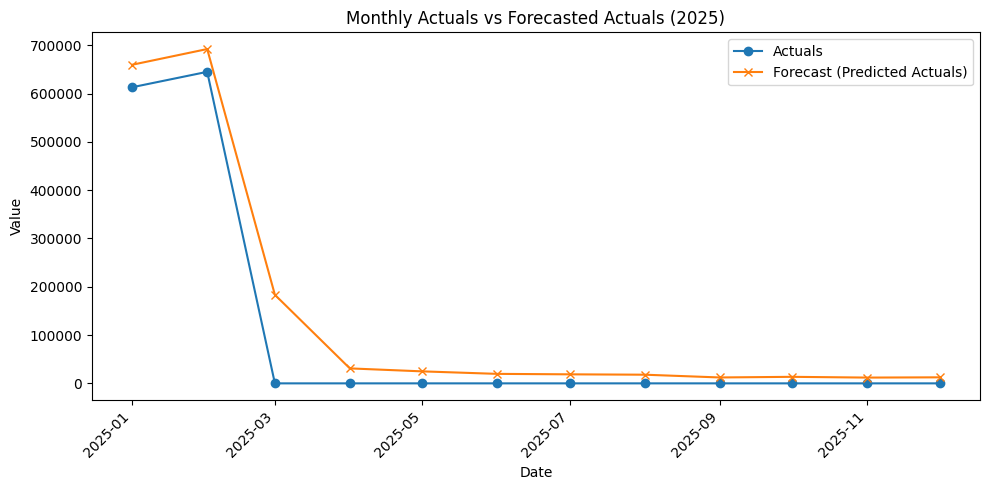

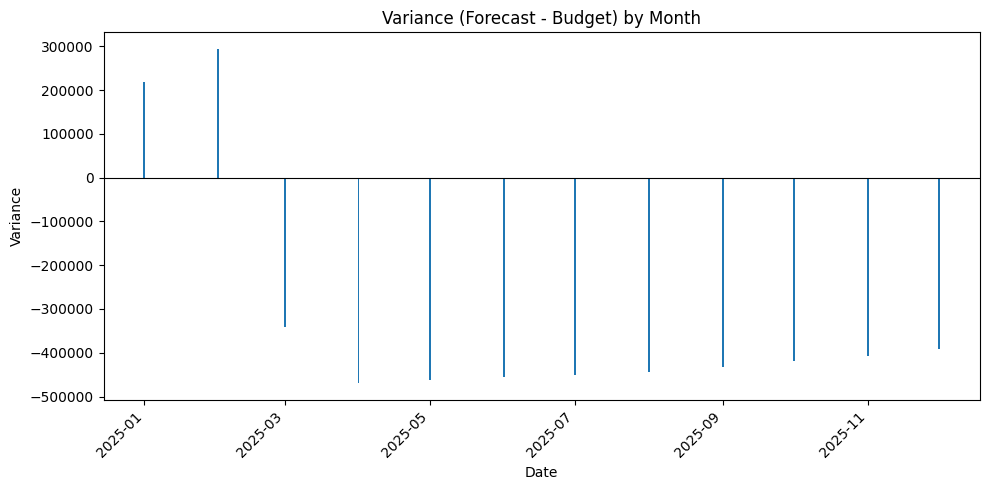

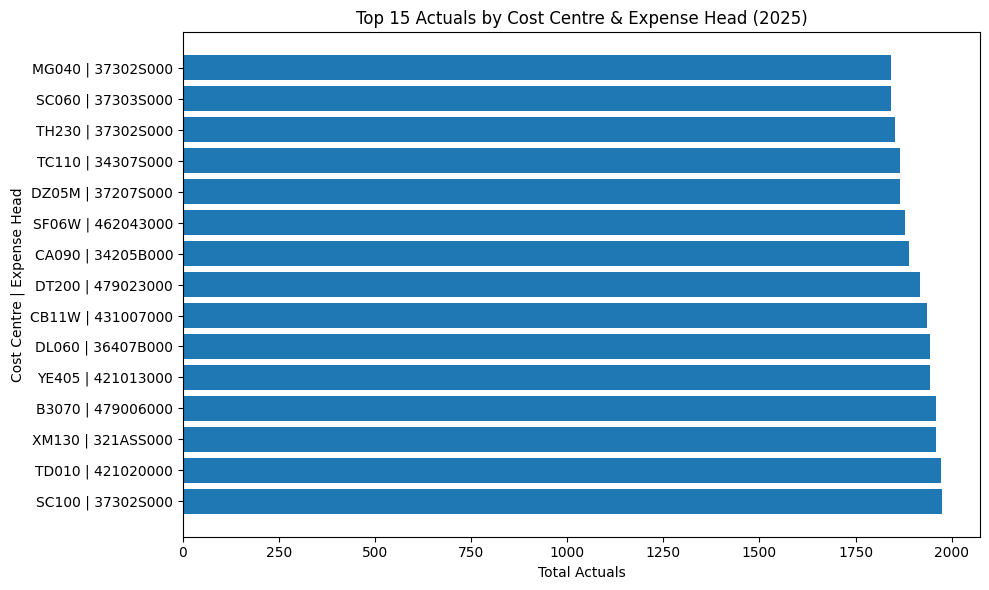

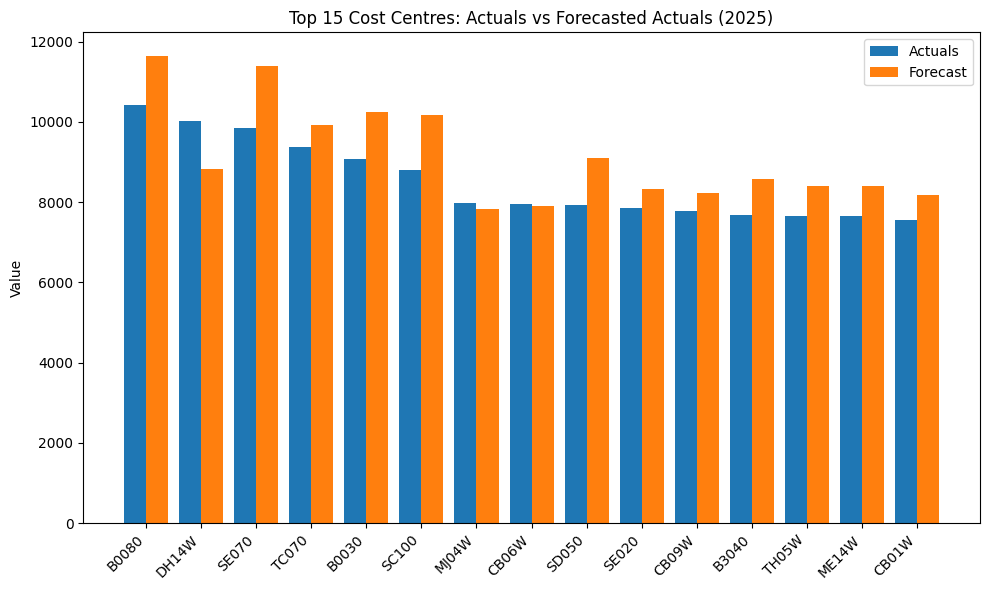

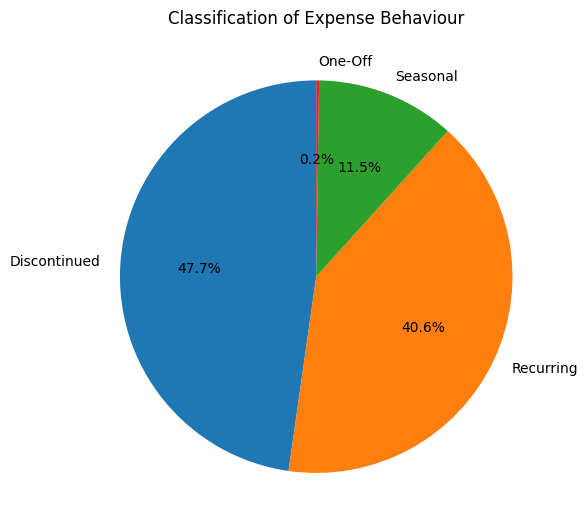

In [ ]:
# =========================================
# Cell 15 — Visualization suite
# =========================================
import matplotlib.pyplot as plt

# --- 1) Actuals vs Forecasted Actuals (monthly totals) ---
monthly_af = (preview.groupby('date', as_index=False)[['actuals','forecast']].sum())

plt.figure(figsize=(10,5))
plt.plot(monthly_af['date'], monthly_af['actuals'], label='Actuals', marker='o')
plt.plot(monthly_af['date'], monthly_af['forecast'], label='Forecast (Predicted Actuals)', marker='x')
plt.title(f"Monthly Actuals vs Forecasted Actuals ({HOLDOUT_YEAR_STR})")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2) Variance: Budget vs Predicted Actuals (monthly totals) ---
budget_cols = eff[['cost_centre','expense_head','date','budget_effective']].copy()
budget_cols = budget_cols.rename(columns={'budget_effective':'budget'})
preview_budget = preview.merge(budget_cols, on=['cost_centre','expense_head','date'], how='left')

monthly_fb = (preview_budget
              .groupby('date', as_index=False)[['forecast','budget']].sum())
monthly_fb['variance_fb'] = monthly_fb['forecast'] - monthly_fb['budget']

plt.figure(figsize=(10,5))
plt.bar(monthly_fb['date'], monthly_fb['variance_fb'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Variance (Forecast - Budget) by Month")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3) Top Actuals by Cost Centre + Expense Head (holdout year totals) ---
drivers_ce = (preview.groupby(['cost_centre','expense_head'], as_index=False)['actuals']
              .sum().sort_values('actuals', ascending=False).head(15))

plt.figure(figsize=(10,6))
plt.barh(drivers_ce['cost_centre'] + " | " + drivers_ce['expense_head'],
         drivers_ce['actuals'])
plt.title(f"Top 15 Actuals by Cost Centre & Expense Head ({HOLDOUT_YEAR_STR})")
plt.xlabel("Total Actuals")
plt.ylabel("Cost Centre | Expense Head")
plt.tight_layout()
plt.show()

# --- 4) Drilldown by Cost Centre (holdout year totals, predicted vs actuals) ---
drivers_cc = (preview.groupby('cost_centre', as_index=False)[['actuals','forecast']]
              .sum().sort_values('actuals', ascending=False).head(15))

plt.figure(figsize=(10,6))
bar_width = 0.4
x = range(len(drivers_cc))
plt.bar([i - bar_width/2 for i in x], drivers_cc['actuals'], width=bar_width, label='Actuals')
plt.bar([i + bar_width/2 for i in x], drivers_cc['forecast'], width=bar_width, label='Forecast')
plt.xticks(x, drivers_cc['cost_centre'], rotation=45, ha='right')
plt.title(f"Top 15 Cost Centres: Actuals vs Forecasted Actuals ({HOLDOUT_YEAR_STR})")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) Classification of Expense Behaviour (distribution) ---
if 'behavior_final' in labels.columns:
    behavior_counts = labels.groupby('behavior_final').size().sort_values(ascending=False)

    plt.figure(figsize=(6,6))
    plt.pie(behavior_counts, labels=behavior_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title("Classification of Expense Behaviour")
    plt.tight_layout()
    plt.show()
else:
    print("[Info] No behavior_final column in labels; skipping classification plot.")

In [ ]:
import pandas as pd

# Ensure 'labels' and 'eff' exist
if 'labels' in globals() and 'eff' in globals() and 'behavior_final' in labels.columns and 'actual_effective' in eff.columns:
    # Merge actuals from eff into labels
    labels_with_actuals = labels.merge(
        eff[['cost_centre','expense_head','date','actual_effective']],
        on=['cost_centre','expense_head','date'],
        how='left'
    )
    labels_with_actuals['actual_effective'] = pd.to_numeric(labels_with_actuals['actual_effective'], errors='coerce').fillna(0.0)

    # Calculate total actuals by behavior_final
    expense_by_behavior = labels_with_actuals.groupby('behavior_final')['actual_effective'].sum().sort_values(ascending=False)

    if expense_by_behavior.empty:
        print("No expense data found for behavior classifications.")
    else:
        # Print the total expense by behavior classification
        print("\n=== Total Expense by Behavior Classification ===")
        print(expense_by_behavior.to_string())
else:
    print("[Info] Required data ('labels', 'eff') or columns ('behavior_final', 'actual_effective') not found.")


=== Total Expense by Behavior Classification ===
behavior_final
Recurring       27415434.77
Seasonal         7759147.45
One-Off           757125.41
Discontinued          23.71


Excluding 'Discontinued' from the pie chart as its total expense is very small.


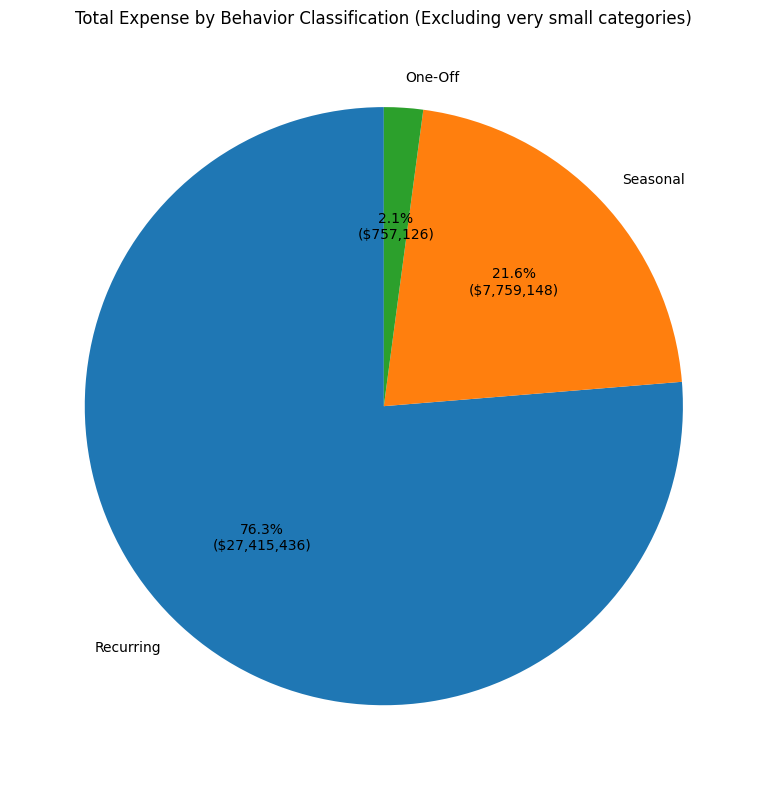

In [ ]:
# =========================================
# Cell X — Pie chart: Total Expense by Behavior Classification
# =========================================
import matplotlib.pyplot as plt

# Ensure 'labels' and 'eff' exist
if 'labels' in globals() and 'eff' in globals() and 'behavior_final' in labels.columns and 'actual_effective' in eff.columns:
    # Merge actuals from eff into labels
    labels_with_actuals = labels.merge(
        eff[['cost_centre','expense_head','date','actual_effective']],
        on=['cost_centre','expense_head','date'],
        how='left'
    )
    labels_with_actuals['actual_effective'] = pd.to_numeric(labels_with_actuals['actual_effective'], errors='coerce').fillna(0.0)

    # Calculate total actuals by behavior_final
    expense_by_behavior = labels_with_actuals.groupby('behavior_final')['actual_effective'].sum().sort_values(ascending=False)

    if expense_by_behavior.empty:
        print("No expense data found for behavior classifications.")
    else:
        # Filter out zero or near-zero values for better visualization
        expense_by_behavior = expense_by_behavior[abs(expense_by_behavior) > 1e-6]

        # Exclude 'Discontinued' category for better visibility of others if it's very small
        if 'Discontinued' in expense_by_behavior.index and expense_by_behavior['Discontinued'] < expense_by_behavior.sum() * 0.001: # Filter if less than 0.1%
             print("Excluding 'Discontinued' from the pie chart as its total expense is very small.")
             expense_by_behavior = expense_by_behavior.drop('Discontinued')

        if expense_by_behavior.empty:
            print("All expense totals are zero or near-zero after filtering.")
        else:
            plt.figure(figsize=(8, 8))
            # Use the actual expense values for autopct and format them nicely
            def autopct_format(values):
                def my_format(pct):
                    total = sum(values)
                    val = int(round(pct*total/100.0))
                    return '{:.1f}%\n(${:,.0f})'.format(pct, val)
                return my_format

            plt.pie(expense_by_behavior, labels=expense_by_behavior.index, autopct=autopct_format(expense_by_behavior), startangle=90)
            plt.title("Total Expense by Behavior Classification (Excluding very small categories)")
            plt.tight_layout()
            plt.show()
else:
    print("[Info] Required data ('labels', 'eff') or columns ('behavior_final', 'actual_effective') not found. Skipping Expense by Behavior plot.")

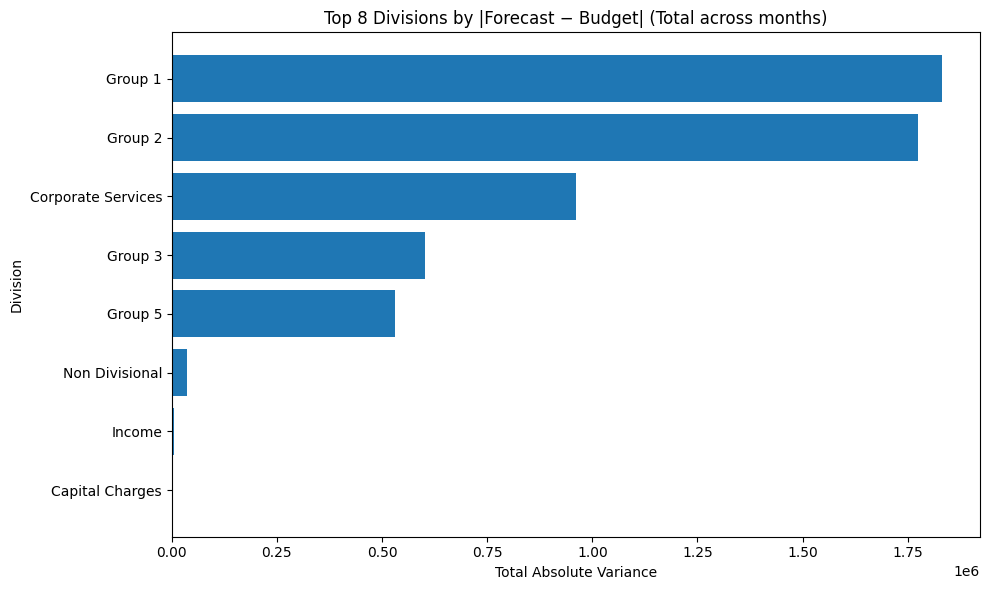

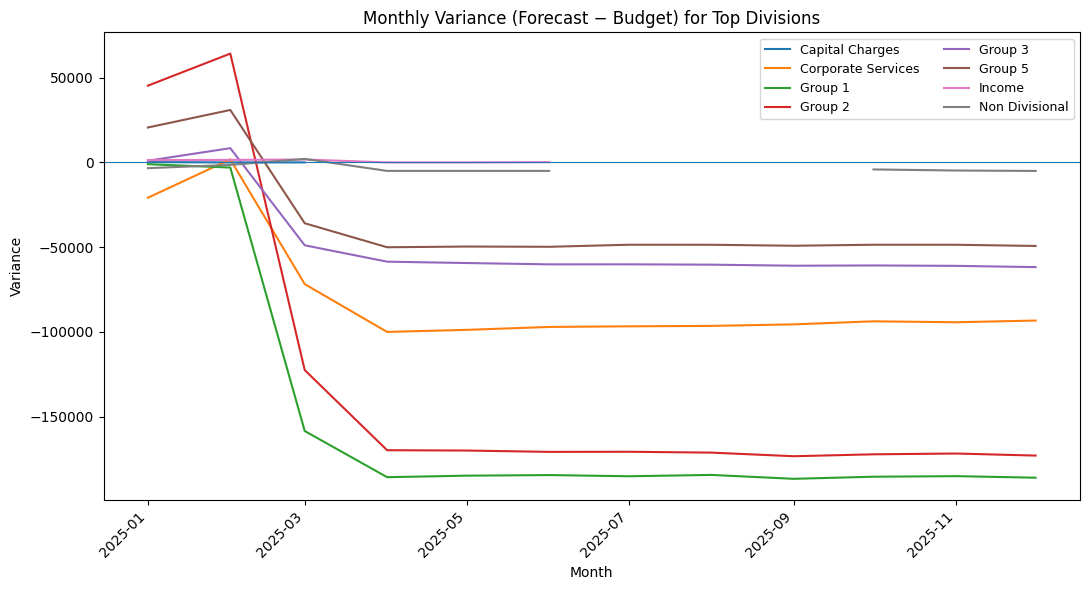

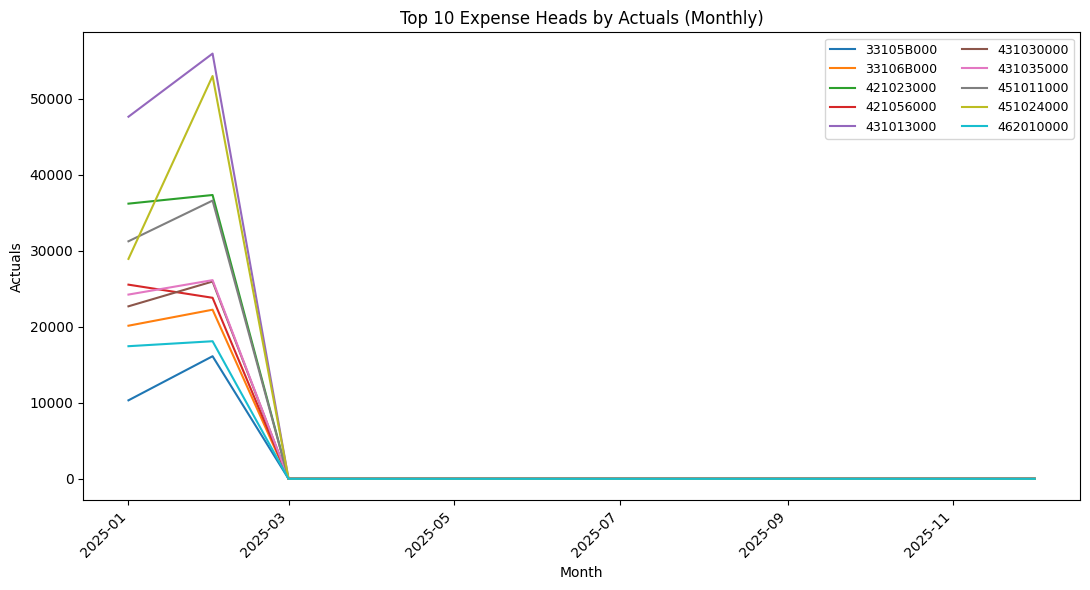

In [ ]:
# =========================================
# Plots: Division variance (Forecast vs Budget) + Top Expense Head lines (robust)
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TOP_N_DIVISIONS = 10
TOP_N_EXPENSE_HEADS = 10
USE_FISCAL_ORDER = True  # Apr = 1 → Mar = 12

def attach_division_cc(df, cost_lookup):
    out = df.copy()
    if 'cost_centre' in out.columns and ('cost_lookup' in globals()) and (cost_lookup is not None) and len(cost_lookup):
        cl = cost_lookup.copy().rename(columns={
            'Cost Centre':'cost_centre',
            'Division':'division',
            'Cost Centre Name':'cost_centre_name',
            'Cost Centre Description':'cost_centre_name'
        })
        keep = [c for c in ['cost_centre','division','cost_centre_name'] if c in cl.columns]
        if keep:
            out = out.merge(cl[keep].drop_duplicates(), on='cost_centre', how='left')
    return out

def add_fiscal_month(df):
    d = df.copy()
    d['fiscal_month'] = ((d['date'].dt.month - 4) % 12) + 1  # Apr=1,...,Mar=12
    return d

# ---------- Checks ----------
if 'preview' not in globals():
    raise RuntimeError("`preview` not found; run forecasting cells first.")
if 'eff' not in globals():
    raise RuntimeError("`eff` not found; run data prep first.")

# ---------- (1) Top variance by division: Forecast - Budget ----------
# Forecast per cost_centre-month from preview
fc_cc = preview.copy()
fc_cc['date'] = pd.to_datetime(fc_cc['date'], errors='coerce')
if 'cost_centre' not in fc_cc.columns or 'forecast' not in fc_cc.columns:
    raise RuntimeError("`preview` must contain 'cost_centre', 'date', 'forecast'. Re-run Cells 10–12.")
fc_cc['forecast'] = pd.to_numeric(fc_cc['forecast'], errors='coerce').fillna(0.0)
fc_cc = fc_cc.groupby(['cost_centre','date'], as_index=False)['forecast'].sum()

# Budget per cost_centre-month from eff
bud_cc = eff.copy()
bud_cc['date'] = pd.to_datetime(bud_cc['date'], errors='coerce')
if 'cost_centre' not in bud_cc.columns or 'budget_effective' not in bud_cc.columns:
    raise RuntimeError("`eff` must contain 'cost_centre', 'date', 'budget_effective'.")
bud_cc['budget'] = pd.to_numeric(bud_cc['budget_effective'], errors='coerce').fillna(0.0)
bud_cc = bud_cc.groupby(['cost_centre','date'], as_index=False)['budget'].sum()

# Merge & variance
pb_cc = fc_cc.merge(bud_cc, on=['cost_centre','date'], how='left').fillna({'budget':0.0})
pb_cc['variance_fb'] = pb_cc['forecast'] - pb_cc['budget']
pb_cc = attach_division_cc(pb_cc, cost_lookup if 'cost_lookup' in globals() else None)

if 'division' in pb_cc.columns and pb_cc['division'].notna().any():
    by_div_month = pb_cc.groupby(['division','date'], as_index=False)['variance_fb'].sum()
    by_div_month['date'] = pd.to_datetime(by_div_month['date'])
    if USE_FISCAL_ORDER:
        by_div_month = add_fiscal_month(by_div_month).sort_values(['division','date'])

    totals = (by_div_month.groupby('division', as_index=False)['variance_fb']
              .apply(lambda s: s.abs().sum())
              .rename(columns={'variance_fb':'abs_variance_total'}))
    top_divs = totals.sort_values('abs_variance_total', ascending=False).head(TOP_N_DIVISIONS)['division'].tolist()

    # Barh: total |variance| by division
    top_totals = totals[totals['division'].isin(top_divs)].sort_values('abs_variance_total')
    plt.figure(figsize=(10,6))
    plt.barh(top_totals['division'], top_totals['abs_variance_total'])
    plt.title(f"Top {len(top_divs)} Divisions by |Forecast − Budget| (Total across months)")
    plt.xlabel("Total Absolute Variance")
    plt.ylabel("Division")
    plt.tight_layout()
    plt.show()

    # Lines: monthly variance for top divisions
    wide = (by_div_month[by_div_month['division'].isin(top_divs)]
            .pivot(index='date', columns='division', values='variance_fb')
            .sort_index())
    plt.figure(figsize=(11,6))
    for col in wide.columns:
        plt.plot(wide.index, wide[col], label=str(col))
    plt.axhline(0, linewidth=0.8)
    plt.title("Monthly Variance (Forecast − Budget) for Top Divisions")
    plt.xlabel("Month")
    plt.ylabel("Variance")
    plt.xticks(rotation=45, ha='right')
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("[Info] No 'division' available (or all NaN). Merge a cost lookup to enable division plots.")

# ---------- (2) Top Expense Heads by Actuals (lines across months) ----------
eh_src = eff.copy()  # use eff so 'expense_head' is guaranteed
eh_src['date'] = pd.to_datetime(eh_src['date'], errors='coerce')
if 'expense_head' not in eh_src.columns or 'actual_effective' not in eh_src.columns:
    print("[Info] Cannot plot expense heads: 'expense_head' or 'actual_effective' missing in eff.")
else:
    # Use the holdout window; comment this block if you want full history
    mask = (eh_src['date'] >= pd.to_datetime(HOLDOUT_START)) & (eh_src['date'] <= pd.to_datetime(HOLDOUT_END))
    eh = eh_src[mask].copy()

    eh['actuals'] = pd.to_numeric(eh['actual_effective'], errors='coerce').fillna(0.0)

    eh_tot = (eh.groupby('expense_head', as_index=False)['actuals'].sum()
                .sort_values('actuals', ascending=False)
                .head(TOP_N_EXPENSE_HEADS))
    top_heads = eh_tot['expense_head'].tolist()

    # name map (safe): start with codes
    name_map = {k: str(k) for k in top_heads}
    if 'exp_lookup' in globals() and exp_lookup is not None and len(exp_lookup):
        el = exp_lookup.copy().rename(columns={
            'Expense Head':'expense_head',
            'Expense Name':'expense_name',
            'Expense Description':'expense_name'
        })
        if 'expense_head' in el.columns and 'expense_name' in el.columns:
            override = dict(zip(el['expense_head'], el['expense_name']))
            # only update those we plot
            name_map.update({k: override.get(k, name_map[k]) for k in top_heads})

    # Monthly actuals for top heads
    eh_month = (eh[eh['expense_head'].isin(top_heads)]
                .groupby(['date','expense_head'], as_index=False)['actuals'].sum()
                .sort_values(['expense_head','date']))
    if eh_month.empty:
        print("[Info] No data for selected expense heads in the chosen window.")
    else:
        wide_eh = eh_month.pivot(index='date', columns='expense_head', values='actuals').sort_index()

        plt.figure(figsize=(11,6))
        for col in wide_eh.columns:
            plt.plot(wide_eh.index, wide_eh[col], label=name_map.get(col, str(col)))
        plt.title(f"Top {len(top_heads)} Expense Heads by Actuals (Monthly)")
        plt.xlabel("Month")
        plt.ylabel("Actuals")
        plt.xticks(rotation=45, ha='right')
        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()


In [ ]:
# =========================================
# Cell 16 — Sample One-Offs inspection
# =========================================

# Make sure 'labels' exists with behavior_final column
if 'behavior_final' in labels.columns:
    one_offs = labels[labels['behavior_final'] == 'One-off'].copy()

    if one_offs.empty:
        print("No One-Offs detected in labels.")
    else:
        # Merge in actual values for context
        one_offs = one_offs.merge(
            eff[['cost_centre','expense_head','date','actual_effective']],
            on=['cost_centre','expense_head','date'],
            how='left'
        )

        # Sort by date for readability
        one_offs = one_offs.sort_values(['cost_centre','expense_head','date'])

        print(f"=== One-Off examples (showing up to 20 rows) ===")
        print(one_offs[['cost_centre','expense_head','date','actual_effective','behavior_final']].head(20).to_string(index=False))

        # Save full list to Drive for finance validation
        OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
        one_offs.to_csv(OUT_DIR/'one_off_examples.csv', index=False)
        print("\nSaved full One-Offs list to:", OUT_DIR/'one_off_examples.csv')
else:
    print("[Info] No behavior_final column in labels; re-run classifier/overrides step first.")


No One-Offs detected in labels.


In [ ]:
# Quick diag: what labels do we actually have?
print("Unique behavior_final values:", labels['behavior_final'].dropna().unique())

# Normalize for filtering (handles One-off / One-Off / one off / one-off)
norm = labels.copy()
norm['behavior_final_norm'] = (
    norm['behavior_final'].astype(str).str.replace(r'[_\s]+', '-', regex=True).str.lower()
)

one_offs = norm[norm['behavior_final_norm'] == 'one-off'].copy()

if one_offs.empty:
    print("Still no One-Offs after normalization.")
else:
    # Add actuals for context
    one_offs = one_offs.merge(
        eff[['cost_centre','expense_head','date','actual_effective']],
        on=['cost_centre','expense_head','date'],
        how='left'
    ).sort_values(['cost_centre','expense_head','date'])

    print(f"\n=== One-Off examples (up to 20 rows) ===")
    print(one_offs[['cost_centre','expense_head','date','actual_effective','behavior_final']].head(20).to_string(index=False))

    # Save full list
    from pathlib import Path
    OUT_DIR = Path('/content/drive/MyDrive/ai_pipeline_summaries')
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    one_offs.to_csv(OUT_DIR/'one_off_examples.csv', index=False)
    print("\nSaved:", OUT_DIR/'one_off_examples.csv')


Unique behavior_final values: ['Recurring' 'Discontinued' 'One-Off' 'Seasonal']

=== One-Off examples (up to 20 rows) ===
cost_centre expense_head       date  actual_effective behavior_final
      11021    121001000 2022-06-01            130.00        One-Off
      11431    115109000 2024-12-01            650.00        One-Off
      B0010    137050000 2021-08-01            200.18        One-Off
      B0010    421026000 2023-03-01            756.80        One-Off
      B0010    421026000 2024-08-01            757.03        One-Off
      B0010    451011000 2022-07-01            207.18        One-Off
      B0010    476003000 2021-08-01            450.00        One-Off
      B0020    137050000 2021-08-01            398.44        One-Off
      B0020    3458AS000 2022-03-01            112.30        One-Off
      B0020    37305S000 2022-06-01            147.01        One-Off
      B0030    33104B000 2021-11-01            728.18        One-Off
      B0030    33104B000 2023-09-01            788

In [ ]:
import pandas as pd

# Load monthly totals
monthly = pd.read_csv(f"/content/drive/MyDrive/ai_pipeline_summaries/monthly_totals_{HOLDOUT_YEAR_STR}.csv")
monthly['date'] = pd.to_datetime(monthly['date'])

# Add variance
monthly['variance'] = monthly['actuals'] - monthly['forecast']

# Fiscal month (Apr = 1, ..., Mar = 12)
monthly['fiscal_month'] = ((monthly['date'].dt.month - 4) % 12) + 1
monthly['fiscal_label'] = monthly['date'].dt.strftime('%b-%Y')

# Order table
table = (monthly[['fiscal_month','fiscal_label','actuals','forecast','variance']]
         .sort_values('fiscal_month'))

# Round nicely
table['actuals']  = table['actuals'].round(2)
table['forecast'] = table['forecast'].round(2)
table['variance'] = table['variance'].round(2)

# Make pandas print "bigger" tables
pd.set_option("display.max_rows", None)      # show all rows
pd.set_option("display.max_columns", None)   # show all cols
pd.set_option("display.width", 120)          # adjust line width
pd.set_option("display.colheader_justify", "center")  # align headers
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"\n=== Actuals vs Forecast by Fiscal Month (Apr → Mar for {HOLDOUT_YEAR_STR}) ===")
print(table.to_string(index=False))


=== Actuals vs Forecast by Fiscal Month (Apr → Mar for 2025) ===
 fiscal_month fiscal_label   actuals   forecast   variance 
       1        Apr-2024   670,534.24 688,104.80 -17,570.56
       2        May-2024   654,855.50 656,123.56  -1,268.06
       3        Jun-2024   678,476.71 676,067.75   2,408.96
       4        Jul-2024   741,806.88 741,881.75     -74.87
       5        Aug-2024   680,002.48 667,666.44  12,336.04
       6        Sep-2024   664,596.54 650,152.30  14,444.24
       7        Oct-2024   684,509.41 695,339.70 -10,830.29
       8        Nov-2024   711,547.33 694,580.70  16,966.63
       9        Dec-2024   740,792.62 714,050.40  26,742.22
      10        Jan-2024   646,586.64 658,718.25 -12,131.61
      11        Feb-2024   681,367.12 701,624.40 -20,257.28
      12        Mar-2024   687,707.99 692,586.00  -4,878.01
